# Inicializando os dados

In [145]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [146]:
import torch
import matplotlib.pyplot as plt
import os

from torchvision.datasets import CIFAR10

In [147]:
DATA_DIR = '/content/drive/MyDrive/datasets/cifar10'
CATEGORIES = ['aviao', 'automovel', 'passaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhao']

In [148]:
cifar10_train = CIFAR10(DATA_DIR, train = True, download=True)
cifar10_test = CIFAR10(DATA_DIR, train = False, download= True)

In [149]:
(len(cifar10_train)), (len(cifar10_test))

(50000, 10000)

In [150]:
def lookat_dataset(dataset, isTensor = False):
  figure = plt.figure(figsize=(8,8))
  rows,cols = 2,2
  for i in range(1,5):
    sample_idx = torch.randint(len(dataset), size=(1, )).item()
    img, label = dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(CATEGORIES[label])
    plt.axis("off")
    if isTensor:
      plt.imshow(img.squeeze().permute(1,2,0))
    else:
      plt.imshow(img)
  plt.show

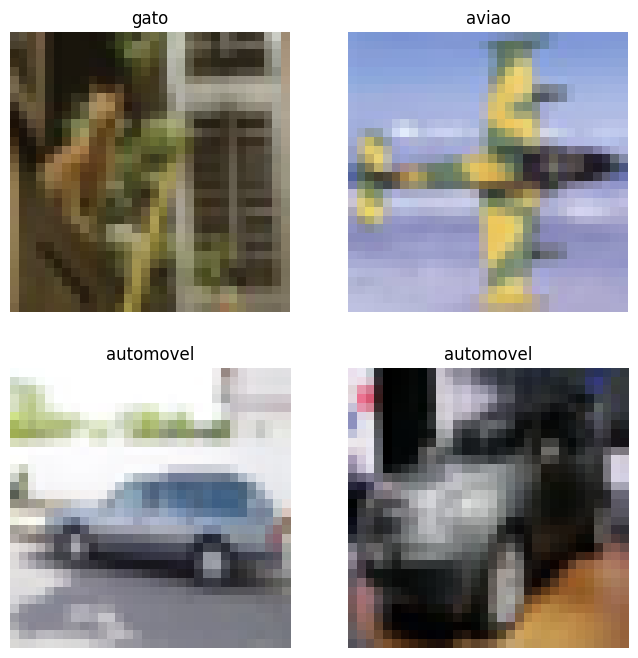

In [151]:
lookat_dataset(cifar10_train)

# Pré-processamento dos dados

In [152]:
import torchvision.transforms as T

In [153]:
from ast import Dict
prep_transform = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2470, 0.2435, 0.2616)
        )
    ]
)

tensor_train = CIFAR10(DATA_DIR, train=True, download=False, transform = prep_transform)
tensor_test = CIFAR10(DATA_DIR, train=False, download=False, transform= prep_transform)



In [154]:
imgs = torch.stack([img_t for img_t, _ in tensor_train], dim = 3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [155]:
imgs.view(3, -1).mean(dim = 1)

tensor([-1.2762e-06, -1.7074e-04,  1.1819e-04])

In [156]:
imgs.view(3, -1).std(dim = 1)

tensor([1.0001, 0.9999, 1.0000])

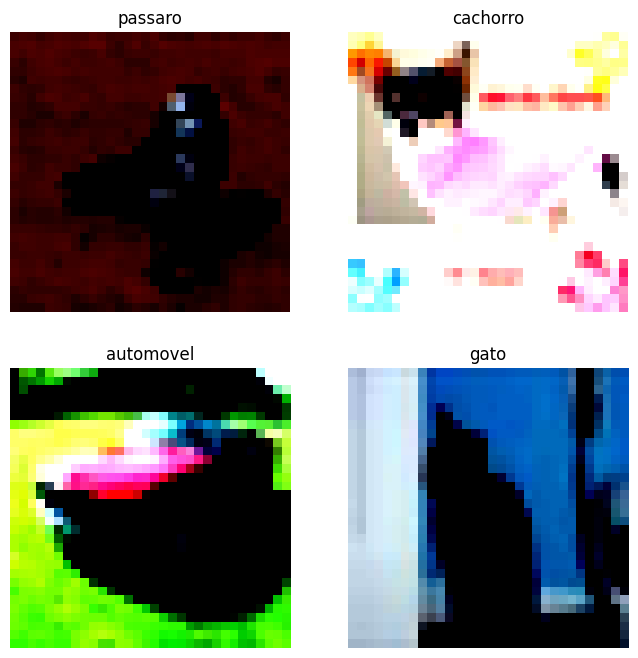

In [157]:
lookat_dataset(tensor_train, True)

# Criando DataLoaders

In [158]:
from torch.utils.data import DataLoader

In [159]:
batch_size =  64
train_loader = DataLoader(tensor_train, batch_size = batch_size, shuffle= True)
test_loader = DataLoader(tensor_test, batch_size= batch_size, shuffle=False)

# Construindo MLP - MultiLayer Perceptron

In [160]:
from torch import nn

In [161]:
class MLPClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.flatten = nn.Flatten() #planifica a matriz (a imagem) - cria um vetor com todos os dados da imagem

    self.layers = nn.Sequential(
        nn.Linear(32*32*3, 256),#pois estamos lidando com imagens 32x32 e como cada imagem possui 3 cores (rgb) temos mais três informações para cada pixel
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,16),
        nn.ReLU(),
        nn.Linear(16,10) #como temos dez classes de objetos temos que no final receber um "vetor" de tamanho 10 com a probabilidade de ser cada tipo de objeto

    )

  def forward(self,image):
    v = self.flatten(image )
    return self.layers(v)

In [162]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Rodando em {device}')

Rodando em cuda


In [163]:
model = MLPClassifier().to(device)

## Escolhendo Hiperparâmetros

In [164]:
optimizer = torch.optim.SGD(model.parameters(), lr =0.001)
loss_func = nn.CrossEntropyLoss()


In [165]:
def train(model, dataloader, loss_func, optimizer):
  model.train()
  cumloss = 0.0

  for imgs, labels in dataloader:
    imgs, labels = imgs.to(device), labels.to(device)
    pred = model(imgs)

    loss = loss_func(pred, labels)
    #zera os gradientes acumulados
    optimizer.zero_grad()
    #computa os gradientes
    loss.backward()
    # anda no sentido de diminuir o gradiente, ou seja, reduz o erro local
    optimizer.step()

    cumloss += loss.item()

    return cumloss/len(dataloader)

def validate(model, dataloader, lossfunc):
  model.eval()
  cumloss = 0.0

  with torch.no_grad():
    for imgs, labels in dataloader:
      imgs, labels = imgs.to(device), labels.to(device)
      pred = model(imgs)
      loss = loss_func(pred, labels)
      cumloss += loss.item()

  return cumloss/len(dataloader)



In [166]:
def plot_losses(losses):
  fig = plt.figure(figsize = (13,5))
  ax = fig.gca()

  for loss_name, loss_values in losses.items():
    ax.plot(loss_values, label = loss_name)
    ax.set_xlabel("Interation", fontsize='16')
    ax.set_ylabel("Loss", fontsize = '16')
    ax.set_title("Loss vs Iteration", fontsize = '16')

In [167]:
epochs = 31
train_losses = []
test_losses = []
for t in range(epochs):
  train_loss = train(model, train_loader, loss_func, optimizer)
  train_losses.append(train_loss)
  if t % 10 == 0:
    print(f'Epoca: {t} Train Loss: {train_loss}')
  test_loss = validate(model, test_loader, loss_func)
  test_losses.append(test_loss)

Epoca: 0 Train Loss: 0.002928651507248354
Epoca: 10 Train Loss: 0.002940616644251987
Epoca: 20 Train Loss: 0.0029712144066305723
Epoca: 30 Train Loss: 0.0029703771976558753


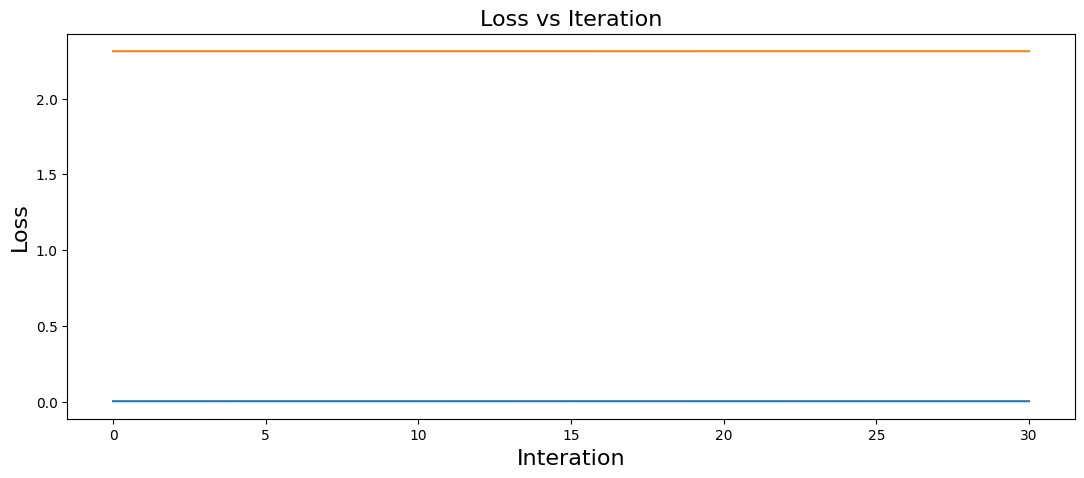

In [168]:
losses = {"Train loss": train_losses, "Test loss": test_losses}
plot_losses(losses)